## ------------------------------------------
## TELCO CUSTOMER CHURN -> MODEL BUILDING
## Goal: Train Logistic Regression and XGBoost,
## compare class_weight vs SMOTE, evaluate using
## AUC-ROC and Recall
## ------------------------------------------

### Basic Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

### Loading Preprocess Data

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 21)
X_test shape: (1407, 21)
y_train shape: (5625,)
y_test shape: (1407,)


### Baseline Model: Logistic Regression (class_weight='balanced')

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix, classification_report) 

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Predictions

In [6]:
y_pred_lr = log_reg.predict(X_test)

# Probability that customer will churn
y_pred_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Metrics# Metrics
print("LOGISTIC REGRESSION (class_weight='balanced')")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION (class_weight='balanced')
Accuracy:  0.7292
Precision: 0.4941
Recall:    0.7888
F1 Score:  0.6076
AUC-ROC:   0.8331

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



### Confusion Matrix Visualization

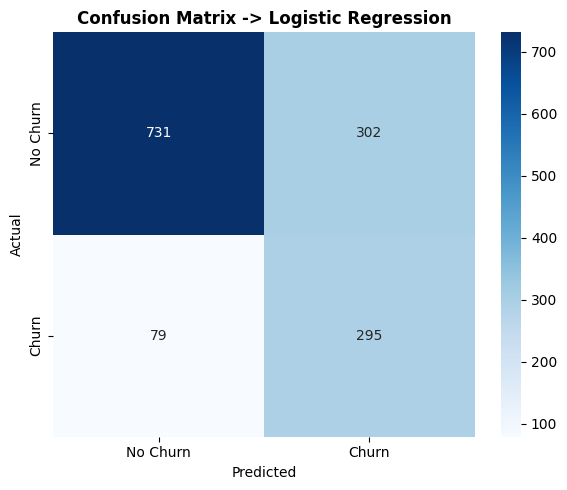

True Negatives:  731 (correctly predicted no churn)
False Positives: 302 (predicted churn, actually stayed)
False Negatives: 79 (predicted stayed, actually churned -> MISSED)
True Positives:  295 (correctly predicted churn)


In [7]:
# Visualize True Positives, False Positives,
# True Negatives, False Negatives

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix -> Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"True Negatives:  {cm_lr[0][0]} (correctly predicted no churn)")
print(f"False Positives: {cm_lr[0][1]} (predicted churn, actually stayed)")
print(f"False Negatives: {cm_lr[1][0]} (predicted stayed, actually churned -> MISSED)")
print(f"True Positives:  {cm_lr[1][1]} (correctly predicted churn)")

### XGBoost with scale_pos_weight

In [8]:
# XGBOOST — scale_pos_weight handles imbalance
# scale_pos_weight = (negative class count) / (positive class count)
# Tells XGBoost to weight the minority class (churn)
# proportionally higher during training

from xgboost import XGBClassifier

# Calculating scale_pos_weight from training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

scale_pos_weight: 2.7625


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [9]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [10]:
# Metrics
print("\nXGBOOST (scale_pos_weight)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBOOST (scale_pos_weight)
Accuracy:  0.7434
Precision: 0.5134
Recall:    0.6658
F1 Score:  0.5797
AUC-ROC:   0.8067

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.82      1033
           1       0.51      0.67      0.58       374

    accuracy                           0.74      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.74      0.75      1407



### Using SMOTE

In [11]:
# SMOTE OVERSAMPLING
# Creates synthetic minority class samples instead of just reweighting.

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


### Retraining Both Models on SMOTE Data

In [12]:
# Note: test set remains the ORIGINAL imbalanced data
# -> As we evaluate on real-world distribution, always

# Logistic Regression on SMOTE data
log_reg_smote = LogisticRegression(random_state=42, max_iter=1000)
log_reg_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = log_reg_smote.predict(X_test)
y_pred_proba_lr_smote = log_reg_smote.predict_proba(X_test)[:, 1]

# XGBoost on SMOTE data
xgb_smote = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_xgb_smote = xgb_smote.predict(X_test)
y_pred_proba_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION (SMOTE)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_smote):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr_smote):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr_smote):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_lr_smote):.4f}")

print("\nXGBOOST (SMOTE)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_smote):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb_smote):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb_smote):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_xgb_smote):.4f}")

LOGISTIC REGRESSION (SMOTE)
Accuracy:  0.7434
Precision: 0.5122
Recall:    0.7273
F1 Score:  0.6011
AUC-ROC:   0.8269

XGBOOST (SMOTE)
Accuracy:  0.7605
Precision: 0.5420
Recall:    0.6390
F1 Score:  0.5865
AUC-ROC:   0.8103


### ROC Curve Comparison

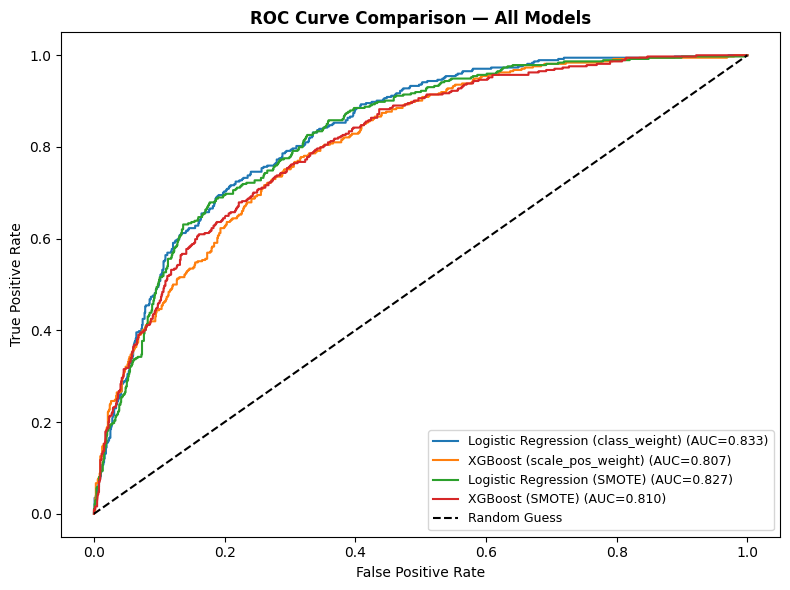

In [13]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

models_proba = {
    'Logistic Regression (class_weight)': y_pred_proba_lr,
    'XGBoost (scale_pos_weight)': y_pred_proba_xgb,
    'Logistic Regression (SMOTE)': y_pred_proba_lr_smote,
    'XGBoost (SMOTE)': y_pred_proba_xgb_smote
}

for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models', fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Random Forest (class_weight='balanced')

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=200
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST (class_weight='balanced')")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

RANDOM FOREST (class_weight='balanced')
Accuracy:  0.7825
Precision: 0.6141
Recall:    0.4893
F1 Score:  0.5446
AUC-ROC:   0.8138


### SHAP Explainability

In [15]:
# SHAP EXPLAINABILITY
# Final model: Logistic Regression (class_weight='balanced')
# SHAP shows WHICH features drive churn predictions and in which direction

import shap

# For linear models, SHAP uses LinearExplainer
explainer = shap.LinearExplainer(log_reg, X_train)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated. Shape:", shap_values.shape)
print("Matches X_test shape:", X_test.shape)

SHAP values calculated. Shape: (1407, 21)
Matches X_test shape: (1407, 21)


### Global Feature Importance (Summary Plot)

- SHAP SUMMARY PLOT -> GLOBAL FEATURE IMPORTANCE
- Shows which features matter most ACROSS ALL customers
- Red = high feature value, Blue = low feature value
- Right of center = pushes toward churn
- Left of center = pushes away from churn

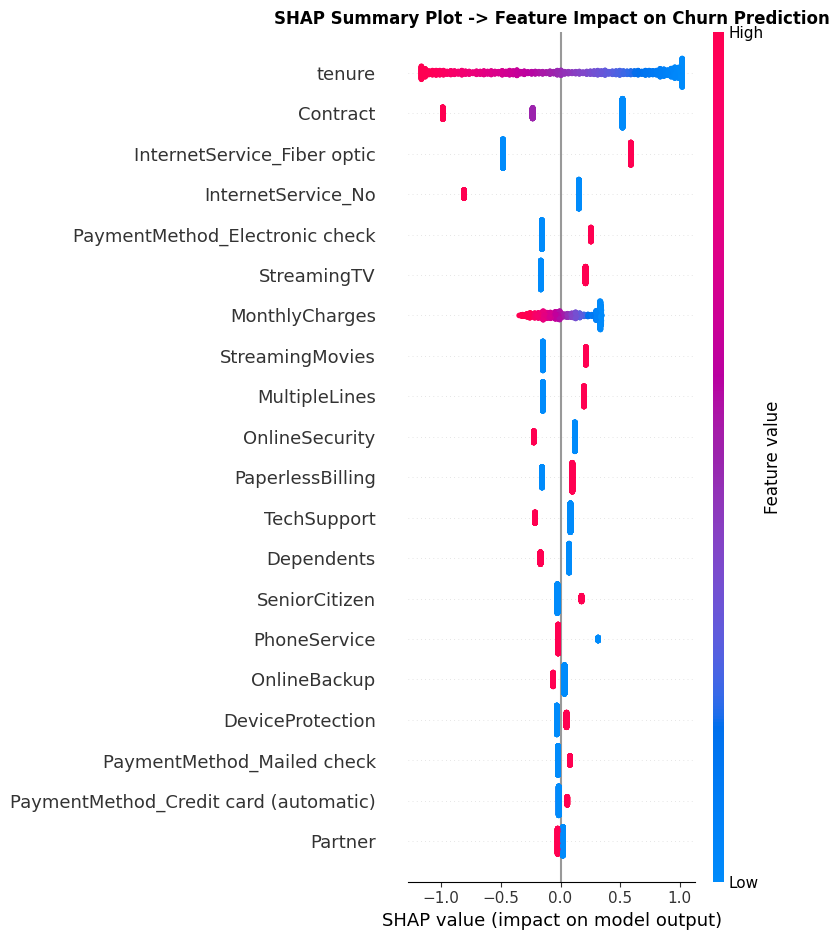

In [16]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot -> Feature Impact on Churn Prediction', fontweight='bold')
plt.tight_layout()
plt.show()